<div class="alert alert-block alert-success">
  <h3><center>MSDS-462: Computer Vision</center></h3>
  <h2><center>Brain Tumor Classification with Human-Readable MRI Explanations Using Deep Learning</center></h2>
  <h3><center>Fine tuning pretrained DenseNet121 model for 4-class MRI tumor classification.</center></h3>
</div>

<div class="alert alert-block alert-info">
    <h2>Imports & Configuration</h2>
</div>

In [1]:
import os
import time
import random
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
DATA_ROOT = Path('/content/drive/MyDrive/dataset/mri_dataset')
TRAIN_DIR = DATA_ROOT / 'Training'
TEST_DIR = DATA_ROOT / 'Testing'

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
EPOCHS = 15
LR = 1e-4
WEIGHT_DECAY = 1e-4
VAL_SIZE = 0.15
PATIENCE = 4
MIN_DELTA = 1e-4

BEST_MODEL_PATH = 'brain_mri_densenet121_best.pt'
LAST_MODEL_PATH = 'brain_mri_densenet121_last.pt'

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

assert TRAIN_DIR.exists(), f'Training folder not found: {TRAIN_DIR.resolve()}'
assert TEST_DIR.exists(), f'Testing folder not found: {TEST_DIR.resolve()}'

print('TRAIN_DIR:', TRAIN_DIR.resolve())
print('TEST_DIR :', TEST_DIR.resolve())

TRAIN_DIR: /content/drive/MyDrive/dataset/mri_dataset/Training
TEST_DIR : /content/drive/MyDrive/dataset/mri_dataset/Testing


<div class="alert alert-block alert-info">
    <h2>Setting seed for reproducibility and configuring CPU/GPU/MPS</h2>
</div>

In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


set_seed(SEED)
device = get_device()
print('Device:', device)
print('CUDA available:', torch.cuda.is_available())
print('MPS available :', torch.backends.mps.is_available())

Device: cuda
CUDA available: True
MPS available : False


<div class="alert alert-block alert-info">
    <h2>Data Preparation</h2>
</div>

In [ ]:
imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

# Load one base dataset to create stratified train/val indices.
base_train_ds = datasets.ImageFolder(root=TRAIN_DIR)
all_targets = np.array(base_train_ds.targets)
all_indices = np.arange(len(base_train_ds))

train_idx, val_idx = train_test_split(
    all_indices,
    test_size=VAL_SIZE,
    stratify=all_targets,
    random_state=SEED,
)

# Build two datasets with different transforms and then subset with same indices.
train_full = datasets.ImageFolder(root=TRAIN_DIR, transform=train_tfm)
val_full = datasets.ImageFolder(root=TRAIN_DIR, transform=eval_tfm)
test_ds = datasets.ImageFolder(root=TEST_DIR, transform=eval_tfm)

train_ds = Subset(train_full, train_idx)
val_ds = Subset(val_full, val_idx)

class_to_idx = train_full.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
num_classes = len(class_to_idx)

print('Classes:', class_to_idx)
print('Num classes:', num_classes)
print('Train size:', len(train_ds))
print('Val size  :', len(val_ds))
print('Test size :', len(test_ds))

Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Num classes: 4
Train size: 4760
Val size  : 840
Test size : 1600


<div class="alert alert-block alert-info">
    <h2>Loading data and model</h2>
</div>

In [ ]:
pin_memory = (device.type == 'cuda')

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

def build_densenet121(num_classes: int) -> nn.Module:
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model


model = build_densenet121(num_classes=num_classes).to(device)

train_targets = all_targets[train_idx]
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=train_targets,
)
class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
print('Class weights:', class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

Class weights: tensor([1., 1., 1., 1.], device='cuda:0')


<div class="alert alert-block alert-info">
    <h2>Defining Training and Model Evaluation Helpers</h2>
</div>

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    n = 0

    for x, y in tqdm(loader, desc='Train', leave=False):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        n += bs

    return total_loss / max(n, 1)


@torch.no_grad()
def infer_probs(model, loader, device):
    model.eval()
    all_probs = []
    all_y = []
    t0 = time.time()

    for x, y in tqdm(loader, desc='Infer', leave=False):
        x = x.to(device)
        logits = model(x)
        probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()

        all_probs.append(probs)
        all_y.append(y.numpy())

    t1 = time.time()
    probs = np.vstack(all_probs)
    y_true = np.concatenate(all_y)
    elapsed = t1 - t0
    ips = len(y_true) / elapsed if elapsed > 0 else float('inf')

    return probs, y_true, elapsed, ips


def evaluate_multiclass_from_probs(probs, y_true):
    y_pred = np.argmax(probs, axis=1)
    acc = accuracy_score(y_true, y_pred)

    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='weighted',
        zero_division=0,
    )

    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='macro',
        zero_division=0,
    )

    cm = confusion_matrix(y_true, y_pred)

    try:
        auc_ovr = roc_auc_score(y_true, probs, multi_class='ovr', average='macro')
    except Exception:
        auc_ovr = float('nan')

    return {
        'acc': acc,
        'auc_ovr_macro': auc_ovr,
        'prec_weighted': prec_w,
        'rec_weighted': rec_w,
        'f1_weighted': f1_w,
        'prec_macro': prec_m,
        'rec_macro': rec_m,
        'f1_macro': f1_m,
        'cm': cm,
        'y_pred': y_pred,
    }


def save_checkpoint(path, model, class_to_idx, config, best_epoch=None, best_f1_macro=None):
    payload = {
        'model_name': 'densenet121',
        'state_dict': model.state_dict(),
        'class_to_idx': class_to_idx,
        'config': config,
    }
    if best_epoch is not None:
        payload['best_epoch'] = best_epoch
    if best_f1_macro is not None:
        payload['best_f1_macro'] = best_f1_macro

    torch.save(payload, path)


def load_densenet_checkpoint(ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    n_classes = len(ckpt['class_to_idx'])
    model = build_densenet121(num_classes=n_classes).to(device)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()
    return model, ckpt

<div class="alert alert-block alert-info">
    <h2>Training loop</h2>
</div>

In [ ]:
config = {
    'epochs': EPOCHS,
    'lr': LR,
    'weight_decay': WEIGHT_DECAY,
    'batch_size': BATCH_SIZE,
    'seed': SEED,
    'num_workers': NUM_WORKERS,
    'img_size': IMG_SIZE,
    'patience': PATIENCE,
    'min_delta': MIN_DELTA,
    'val_size': VAL_SIZE,
}

best_f1_macro = -1.0
best_epoch = -1
best_metrics = None
epochs_without_improvement = 0
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)

    val_probs, val_y, val_elapsed, val_ips = infer_probs(model, val_loader, device)
    val_metrics = evaluate_multiclass_from_probs(val_probs, val_y)

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'val_acc': val_metrics['acc'],
        'val_f1_macro': val_metrics['f1_macro'],
        'val_f1_weighted': val_metrics['f1_weighted'],
        'val_auc_ovr_macro': val_metrics['auc_ovr_macro'],
    })

    print(f'\nEpoch {epoch}/{EPOCHS}')
    print(f'Train loss: {train_loss:.4f}')
    print(
        f"Val Acc: {val_metrics['acc']:.4f} | "
        f"Val AUC(OVR Macro): {val_metrics['auc_ovr_macro']:.4f}"
    )
    print(
        f"Val Precision(Macro/Weighted): {val_metrics['prec_macro']:.4f}/{val_metrics['prec_weighted']:.4f} | "
        f"Val Recall(Macro/Weighted): {val_metrics['rec_macro']:.4f}/{val_metrics['rec_weighted']:.4f}"
    )
    print(
        f"Val F1(Macro/Weighted): {val_metrics['f1_macro']:.4f}/{val_metrics['f1_weighted']:.4f}"
    )
    print('Val confusion matrix:')
    print(val_metrics['cm'])
    print(f'Val elapsed: {val_elapsed:.2f}s | Throughput: {val_ips:.2f} imgs/s')

    improved = val_metrics['f1_macro'] > (best_f1_macro + MIN_DELTA)
    if improved:
        best_f1_macro = val_metrics['f1_macro']
        best_epoch = epoch
        best_metrics = val_metrics
        epochs_without_improvement = 0

        save_checkpoint(
            BEST_MODEL_PATH,
            model,
            class_to_idx=class_to_idx,
            config=config,
            best_epoch=best_epoch,
            best_f1_macro=best_f1_macro,
        )
        print(f'Saved BEST model to: {BEST_MODEL_PATH}')
    else:
        epochs_without_improvement += 1
        print(f'No improvement for {epochs_without_improvement} epoch(s). Patience: {PATIENCE}')

    if epochs_without_improvement >= PATIENCE:
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        break

save_checkpoint(
    LAST_MODEL_PATH,
    model,
    class_to_idx=class_to_idx,
    config=config,
)
print(f'\nSaved LAST model to: {LAST_MODEL_PATH}')
print(f'Best epoch by val macro F1: {best_epoch} | Best val macro F1: {best_f1_macro:.4f}')

if best_metrics is not None:
    print('Best validation confusion matrix:')
    print(best_metrics['cm'])


Epoch 1/15
Train loss: 0.2956
Val Acc: 0.9595 | Val AUC(OVR Macro): 0.9980
Val Precision(Macro/Weighted): 0.9609/0.9609 | Val Recall(Macro/Weighted): 0.9595/0.9595
Val F1(Macro/Weighted): 0.9597/0.9597
Val confusion matrix:
[[196  13   0   1]
 [  0 198   9   3]
 [  0   1 209   0]
 [  0   7   0 203]]
Val elapsed: 6.42s | Throughput: 130.79 imgs/s
Saved BEST model to: brain_mri_densenet121_best.pt



Epoch 2/15
Train loss: 0.0962
Val Acc: 0.9762 | Val AUC(OVR Macro): 0.9993
Val Precision(Macro/Weighted): 0.9765/0.9765 | Val Recall(Macro/Weighted): 0.9762/0.9762
Val F1(Macro/Weighted): 0.9761/0.9761
Val confusion matrix:
[[205   3   0   2]
 [  2 197   2   9]
 [  0   1 209   0]
 [  0   1   0 209]]
Val elapsed: 6.69s | Throughput: 125.64 imgs/s
Saved BEST model to: brain_mri_densenet121_best.pt



Epoch 3/15
Train loss: 0.0535
Val Acc: 0.9786 | Val AUC(OVR Macro): 0.9995
Val Precision(Macro/Weighted): 0.9796/0.9796 | Val Recall(Macro/Weighted): 0.9786/0.9786
Val F1(Macro/Weighted): 0.9787/0.9787
Val confusion matrix:
[[202   8   0   0]
 [  0 209   1   0]
 [  0   1 209   0]
 [  2   6   0 202]]
Val elapsed: 7.47s | Throughput: 112.41 imgs/s
Saved BEST model to: brain_mri_densenet121_best.pt



Epoch 4/15
Train loss: 0.0393
Val Acc: 0.9893 | Val AUC(OVR Macro): 0.9998
Val Precision(Macro/Weighted): 0.9893/0.9893 | Val Recall(Macro/Weighted): 0.9893/0.9893
Val F1(Macro/Weighted): 0.9893/0.9893
Val confusion matrix:
[[209   1   0   0]
 [  2 206   1   1]
 [  0   0 209   1]
 [  1   2   0 207]]
Val elapsed: 7.67s | Throughput: 109.59 imgs/s
Saved BEST model to: brain_mri_densenet121_best.pt



Epoch 5/15
Train loss: 0.0405
Val Acc: 0.9869 | Val AUC(OVR Macro): 0.9995
Val Precision(Macro/Weighted): 0.9871/0.9871 | Val Recall(Macro/Weighted): 0.9869/0.9869
Val F1(Macro/Weighted): 0.9869/0.9869
Val confusion matrix:
[[209   0   0   1]
 [  3 202   0   5]
 [  0   2 208   0]
 [  0   0   0 210]]
Val elapsed: 7.53s | Throughput: 111.51 imgs/s
No improvement for 1 epoch(s). Patience: 4



Epoch 6/15
Train loss: 0.0294
Val Acc: 0.9845 | Val AUC(OVR Macro): 0.9998
Val Precision(Macro/Weighted): 0.9850/0.9850 | Val Recall(Macro/Weighted): 0.9845/0.9845
Val F1(Macro/Weighted): 0.9846/0.9846
Val confusion matrix:
[[205   5   0   0]
 [  0 208   1   1]
 [  0   2 208   0]
 [  0   4   0 206]]
Val elapsed: 7.05s | Throughput: 119.10 imgs/s
No improvement for 2 epoch(s). Patience: 4



Epoch 7/15
Train loss: 0.0190
Val Acc: 0.9845 | Val AUC(OVR Macro): 0.9975
Val Precision(Macro/Weighted): 0.9848/0.9848 | Val Recall(Macro/Weighted): 0.9845/0.9845
Val F1(Macro/Weighted): 0.9845/0.9845
Val confusion matrix:
[[209   1   0   0]
 [  2 200   1   7]
 [  0   1 208   1]
 [  0   0   0 210]]
Val elapsed: 6.12s | Throughput: 137.19 imgs/s
No improvement for 3 epoch(s). Patience: 4



Epoch 8/15
Train loss: 0.0187
Val Acc: 0.9869 | Val AUC(OVR Macro): 0.9999
Val Precision(Macro/Weighted): 0.9871/0.9871 | Val Recall(Macro/Weighted): 0.9869/0.9869
Val F1(Macro/Weighted): 0.9869/0.9869
Val confusion matrix:
[[208   2   0   0]
 [  1 207   1   1]
 [  0   1 209   0]
 [  0   5   0 205]]
Val elapsed: 6.99s | Throughput: 120.10 imgs/s
No improvement for 4 epoch(s). Patience: 4

Early stopping triggered at epoch 8.

Saved LAST model to: brain_mri_densenet121_last.pt
Best epoch by val macro F1: 4 | Best val macro F1: 0.9893
Best validation confusion matrix:
[[209   1   0   0]
 [  2 206   1   1]
 [  0   0 209   1]
 [  1   2   0 207]]


<div class="alert alert-block alert-info">
    <h2>Model Evaluation on Test Set</h2>
</div>


===== FINAL TEST RESULTS =====
Test Acc: 0.9469
Test AUC(OVR Macro): 0.9906
Test Precision(Macro/Weighted): 0.9500/0.9500
Test Recall(Macro/Weighted): 0.9469/0.9469
Test F1(Macro/Weighted): 0.9459/0.9459
Test confusion matrix:
Test elapsed: 12.19s | Throughput: 131.23 imgs/s

Classification report (TEST):
              precision    recall  f1-score   support

      glioma       0.99      0.82      0.90       400
  meningioma       0.92      0.97      0.95       400
     notumor       0.90      1.00      0.95       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



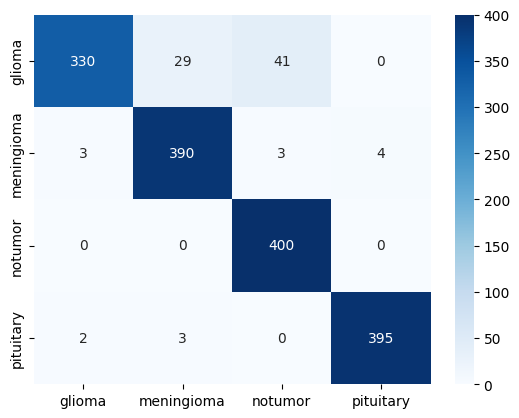

In [ ]:
best_model, best_ckpt = load_densenet_checkpoint(BEST_MODEL_PATH, device)

test_probs, test_y, test_elapsed, test_ips = infer_probs(best_model, test_loader, device)
test_metrics = evaluate_multiclass_from_probs(test_probs, test_y)
test_pred = test_metrics['y_pred']

label_names = [idx_to_class[i] for i in range(num_classes)]

print('\n===== FINAL TEST RESULTS =====')
print(f"Test Acc: {test_metrics['acc']:.4f}")
print(f"Test AUC(OVR Macro): {test_metrics['auc_ovr_macro']:.4f}")
print(
    f"Test Precision(Macro/Weighted): {test_metrics['prec_macro']:.4f}/{test_metrics['prec_weighted']:.4f}"
)
print(
    f"Test Recall(Macro/Weighted): {test_metrics['rec_macro']:.4f}/{test_metrics['rec_weighted']:.4f}"
)
print(
    f"Test F1(Macro/Weighted): {test_metrics['f1_macro']:.4f}/{test_metrics['f1_weighted']:.4f}"
)
print('Test confusion matrix:')
sns.heatmap(test_metrics['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
print(f'Test elapsed: {test_elapsed:.2f}s | Throughput: {test_ips:.2f} imgs/s')

print('\nClassification report (TEST):')
print(classification_report(test_y, test_pred, target_names=label_names, zero_division=0))